In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../population_health.duckdb")

print("Connected to DuckDB")

Connected to DuckDB


In [2]:
query = """

select *
from mart_population_health_risk

"""

risk_df = con.execute(query).df()

risk_df.head()

,member_id,first_name,last_name,state,plan_type,total_claims,total_paid_amount,inpatient_admits,chronic_condition_count,condition_risk_score,outreach_attempts,successful_outreach,engagement_status,population_risk_tier
0,100000,Margaret,Perez,CA,Medicare Advantage,3,2222.40,0.0,1,1.0,4,1.0,Engaged,Low
1,100001,Leslie,Lawson,CA,Commercial,4,3509.56,0.0,1,2.0,2,0.0,Not Engaged,Low
2,100002,Katherine,Smith,NY,Commercial,9,10537.17,0.0,1,2.0,2,0.0,Not Engaged,High
3,100004,Melissa,Leblanc,GA,Commercial,14,11237.57,3.0,1,2.0,3,3.0,Engaged,High
4,100006,John,Gates,GA,Medicare Advantage,1,531.53,0.0,2,3.0,4,1.0,Engaged,Medium


In [3]:
risk_df["population_risk_tier"].value_counts()

population_risk_tier
Medium    2350
High      1641
Low       1009
Name: count, dtype: int64

In [4]:
risk_df.groupby("population_risk_tier")["total_paid_amount"].mean()

population_risk_tier
High      9851.226764
Low       2391.371368
Medium    5706.476953
Name: total_paid_amount, dtype: float64

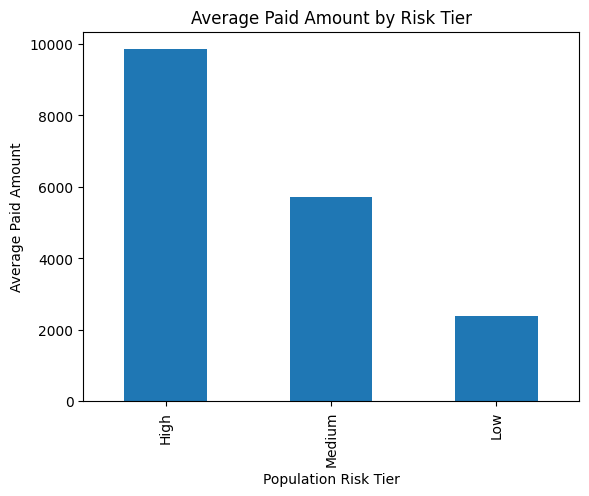

In [5]:
avg_paid = (
    risk_df
    .groupby("population_risk_tier")["total_paid_amount"]
    .mean()
    .sort_values(ascending=False)
)

avg_paid.plot(kind='bar')

plt.title("Average Paid Amount by Risk Tier")
plt.ylabel("Average Paid Amount")
plt.xlabel("Population Risk Tier")

plt.show()

In [6]:
engagement_summary = (
    risk_df
    .groupby("population_risk_tier")["engagement_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

engagement_summary

population_risk_tier  engagement_status
High                  Engaged              50.2
                      Not Engaged          49.8
Low                   Engaged              50.2
                      Not Engaged          49.8
Medium                Engaged              51.0
                      Not Engaged          49.0
Name: proportion, dtype: float64

In [7]:
import plotly.express as px

In [8]:
risk_counts = (
    risk_df["population_risk_tier"]
    .value_counts()
    .reset_index()
)

risk_counts.columns = ["population_risk_tier", "member_count"]

fig = px.bar(
    risk_counts,
    x="population_risk_tier",
    y="member_count",
    title="Member Count by Population Risk Tier",
    text="member_count"
)

fig.show()

In [9]:
avg_paid_by_risk = (
    risk_df
    .groupby("population_risk_tier")["total_paid_amount"]
    .mean()
    .round(2)
    .reset_index()
)

fig = px.bar(
    avg_paid_by_risk,
    x="population_risk_tier",
    y="total_paid_amount",
    title="Average Paid Amount by Risk Tier",
    text="total_paid_amount"
)

fig.show()

In [10]:
engagement_df = (
    risk_df
    .groupby(["population_risk_tier", "engagement_status"])
    .size()
    .reset_index(name="member_count")
)

fig = px.bar(
    engagement_df,
    x="population_risk_tier",
    y="member_count",
    color="engagement_status",
    barmode="group",
    title="Engagement Status by Population Risk Tier"
)

fig.show()

In [11]:
condition_summary = (
    risk_df
    .groupby("population_risk_tier")["chronic_condition_count"]
    .mean()
    .round(2)
    .reset_index()
)

fig = px.bar(
    condition_summary,
    x="population_risk_tier",
    y="chronic_condition_count",
    title="Average Chronic Condition Count by Risk Tier",
    text="chronic_condition_count"
)

fig.show()

In [14]:
summary_kpis = pd.DataFrame({
    "metric": [
        "Total Members",
        "High Risk Members",
        "Engaged Members",
        "Average Paid Amount",
        "Average Chronic Conditions"
    ],
    "value": [
        len(risk_df),
        (risk_df["population_risk_tier"] == "High").sum(),
        (risk_df["engagement_status"] == "Engaged").sum(),
        round(risk_df["total_paid_amount"].mean(), 2),
        round(risk_df["chronic_condition_count"].mean(), 2)
    ]
})

summary_kpis

,metric,value
0,Total Members,5000.00
1,High Risk Members,1641.00
2,Engaged Members,2529.00
3,Average Paid Amount,6397.80
4,Average Chronic Conditions,0.94


In [15]:
top_members = (
    risk_df
    .sort_values(by="total_paid_amount", ascending=False)
    [
        [
            "member_id",
            "first_name",
            "last_name",
            "population_risk_tier",
            "total_paid_amount",
            "chronic_condition_count",
            "engagement_status"
        ]
    ]
    .head(10)
)

top_members

,member_id,first_name,last_name,population_risk_tier,total_paid_amount,chronic_condition_count,engagement_status
62,100115,Sharon,Rhodes,High,18850.97,2,Not Engaged
1920,102026,Stephen,Campbell,High,18396.03,0,Not Engaged
2118,102188,Daniel,Houston,High,18360.64,1,Engaged
1554,100774,Natalie,Nelson,High,18117.55,0,Engaged
4582,104175,Cassidy,Osborne,High,17984.17,3,Not Engaged
4336,104548,Melissa,Clark,High,17746.14,3,Not Engaged
1190,100899,David,Adams,High,17657.02,1,Not Engaged
523,100935,Deborah,Coleman,High,17459.93,1,Engaged
4935,104975,Andre,Thompson,High,17353.82,0,Not Engaged
1015,101908,Brandon,Huff,High,17086.23,2,Not Engaged


In [16]:
fig = px.scatter(
    risk_df,
    x="chronic_condition_count",
    y="total_paid_amount",
    color="population_risk_tier",
    title="Healthcare Cost vs Chronic Condition Burden",
    hover_data=[
        "member_id",
        "engagement_status"
    ]
)

fig.show()

In [17]:
fig = px.box(
    risk_df,
    x="population_risk_tier",
    y="total_paid_amount",
    color="population_risk_tier",
    title="Paid Amount Distribution by Risk Tier"
)

fig.show()

In [18]:
corr_df = risk_df[
    [
        "total_claims",
        "total_paid_amount",
        "inpatient_admits",
        "chronic_condition_count",
        "condition_risk_score",
        "outreach_attempts",
        "successful_outreach"
    ]
]

corr_matrix = corr_df.corr()

fig = px.imshow(
    corr_matrix,
    text_auto=True,
    title="Correlation Matrix of Population Health Metrics"
)

fig.show()

In [19]:
fig = px.scatter(
    risk_df,
    x="condition_risk_score",
    y="total_paid_amount",
    color="engagement_status",
    size="chronic_condition_count",
    hover_data=[
        "member_id",
        "population_risk_tier",
        "state"
    ],
    title="Risk Score vs Healthcare Cost by Engagement Status"
)

fig.show()

# Outreach Success Feature Engineering

This section explores which utilization and chronic condition features may influence successful member engagement and outreach outcomes.

In [20]:
feature_df = risk_df.copy()

feature_df["engaged_flag"] = (
    feature_df["engagement_status"]
    .map({
        "Engaged": 1,
        "Not Engaged": 0
    })
)

feature_df[
    [
        "condition_risk_score",
        "chronic_condition_count",
        "total_claims",
        "total_paid_amount",
        "inpatient_admits",
        "outreach_attempts",
        "engaged_flag"
    ]
].head()

,condition_risk_score,chronic_condition_count,total_claims,total_paid_amount,inpatient_admits,outreach_attempts,engaged_flag
0,1.0,1,3,2222.40,0.0,4,1
1,2.0,1,4,3509.56,0.0,2,0
2,2.0,1,9,10537.17,0.0,2,0
3,2.0,1,14,11237.57,3.0,3,1
4,3.0,2,1,531.53,0.0,4,1


In [21]:
engagement_corr = feature_df[
    [
        "condition_risk_score",
        "chronic_condition_count",
        "total_claims",
        "total_paid_amount",
        "inpatient_admits",
        "outreach_attempts",
        "engaged_flag"
    ]
].corr()

engagement_corr[["engaged_flag"]].sort_values(
    by="engaged_flag",
    ascending=False
)

,engaged_flag
engaged_flag,1.000000
outreach_attempts,0.454977
inpatient_admits,0.004583
total_claims,-0.003168
chronic_condition_count,-0.004198
condition_risk_score,-0.011830
total_paid_amount,-0.013411


In [22]:
fig = px.scatter(
    feature_df,
    x="outreach_attempts",
    y="total_paid_amount",
    color="engagement_status",
    size="condition_risk_score",
    hover_data=[
        "member_id",
        "population_risk_tier"
    ],
    title="Outreach Attempts vs Total Paid Amount"
)

fig.show()